In [1]:
%%capture
!pip -q install kagglehub seaborn scikit-learn


In [2]:
import os
import re
import json
import random
import zipfile
import gc
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import kagglehub

SEED = 42
IMG_SIZE = 224
NUM_CLASSES = 4

# Colab Free friendly defaults (reduce RAM pressure)
BATCH_SIZE = 16
STAGE1_EPOCHS = 6
STAGE2_EPOCHS = 12
AUTOTUNE = tf.data.AUTOTUNE

# Dataset source control:
# - Set True to download from KaggleHub
# - Set False to use ZIP from Google Drive
USE_KAGGLEHUB = False

# Google Drive ZIP path (your requested location)
ZIP_PATH = '/content/drive/MyDrive/Colab Notebooks/MRI_Data_set.zip'
MOUNT_GOOGLE_DRIVE = True
FORCE_REEXTRACT = False
EXTRACT_DIR = '/content/MRI_Data_set_extracted'

CLASS_LABELS = {
    0: 'Non-Demented',
    1: 'Very Mild',
    2: 'Mild',
    3: 'Moderate',
}

RISK_MAP = {
    0: 'low',
    1: 'medium',
    2: 'high',
    3: 'critical',
}

OUTPUT_DIR = Path('/content/mri_artifacts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Output dir:', OUTPUT_DIR)
print('USE_KAGGLEHUB:', USE_KAGGLEHUB)
print('ZIP_PATH:', ZIP_PATH)
print('BATCH_SIZE:', BATCH_SIZE)

TensorFlow: 2.19.0
Output dir: /content/mri_artifacts
USE_KAGGLEHUB: False
ZIP_PATH: /content/drive/MyDrive/Colab Notebooks/MRI_Data_set.zip
BATCH_SIZE: 16


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU detected:', gpus)
else:
    print('GPU not detected. In Colab use Runtime -> Change runtime type -> GPU for faster training.')


GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
def _normalize_name(name: str) -> str:
    return re.sub(r'[^a-z]+', '', name.lower())

def resolve_image_root(base_root: Path) -> Path:
    """
    Resolve the directory that directly contains the 4 class folders.
    Handles common layouts such as:
    - MRI_Data_set/Data/<class_folders>
    - Data/<class_folders>
    - <dataset_root>/<class_folders>
    """
    expected_tokens = {
        'milddementia',
        'moderatedementia',
        'nondemented',
        'verymilddementia',
    }

    candidates = [
        base_root / 'Data',
        base_root / 'MRI_Data_set' / 'Data',
        base_root,
    ]

    # Add any nested folder literally named "Data"
    candidates.extend([p for p in base_root.rglob('*') if p.is_dir() and p.name.lower() == 'data'])

    seen = set()
    for cand in candidates:
        cand = cand.resolve()
        if cand in seen or not cand.exists() or not cand.is_dir():
            continue
        seen.add(cand)

        child_tokens = {
            _normalize_name(p.name)
            for p in cand.iterdir()
            if p.is_dir()
        }

        if expected_tokens.issubset(child_tokens):
            return cand

    raise RuntimeError(
        f'Could not locate class folder root under: {base_root}. '
        'Expected folder layout like MRI_Data_set/Data/<4 class folders>.'
    )

if USE_KAGGLEHUB:
    raw_root = Path(kagglehub.dataset_download('ninadaithal/imagesoasis'))
    print('KaggleHub raw root:', raw_root)
else:
    if MOUNT_GOOGLE_DRIVE:
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
        except Exception as e:
            print('Drive mount skipped/failed:', e)

    zip_file = Path(ZIP_PATH)
    if not zip_file.exists():
        raise FileNotFoundError(
            f'{ZIP_PATH} not found. Confirm file path in Google Drive and notebook settings.'
        )

    raw_root = Path(EXTRACT_DIR)
    needs_extract = FORCE_REEXTRACT or (not raw_root.exists()) or (not any(raw_root.iterdir()))

    if needs_extract:
        raw_root.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_file, 'r') as zf:
            zf.extractall(raw_root)
        print('Extracted zip to:', raw_root)
    else:
        print('Using existing extracted folder:', raw_root)

dataset_root = resolve_image_root(raw_root)
print('Resolved dataset class root:', dataset_root)
print('Class folders found:', [p.name for p in dataset_root.iterdir() if p.is_dir()])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracted zip to: /content/MRI_Data_set_extracted
Resolved dataset class root: /content/MRI_Data_set_extracted/Data
Class folders found: ['Moderate Dementia', 'Mild Dementia', 'Very mild Dementia', 'Non Demented']


In [5]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

def normalize_token(value: str) -> str:
    return re.sub(r'[^a-z]+', '', value.lower())

def infer_class_id(file_path: Path):
    # Search folder names from closest parent outward.
    for part in reversed(file_path.parts):
        token = normalize_token(part)
        if not token:
            continue

        if 'moderate' in token:
            return 3
        if 'verymild' in token:
            return 1
        if 'mild' in token and 'very' not in token:
            return 2
        if 'nondement' in token or ('non' in token and 'dement' in token):
            return 0

    return None

all_images = []
for ext in IMAGE_EXTS:
    all_images.extend(dataset_root.rglob(f'*{ext}'))
    all_images.extend(dataset_root.rglob(f'*{ext.upper()}'))

all_images = sorted(set(all_images))
print('Total image files found:', len(all_images))

records = []
unknown_paths = []
for image_path in all_images:
    class_id = infer_class_id(image_path)
    if class_id is None:
        unknown_paths.append(str(image_path))
        continue
    records.append({'filepath': str(image_path), 'class_id': class_id})

df = pd.DataFrame(records)

if len(unknown_paths) > 0:
    print(f'Warning: skipped {len(unknown_paths)} files with unknown class folders.')

if df.empty:
    raise RuntimeError('No labeled images discovered. Check dataset structure and class folder names.')

counts = df['class_id'].value_counts().sort_index()
print('Class counts:')
for class_id in range(NUM_CLASSES):
    count = int(counts.get(class_id, 0))
    print(f'  {class_id} ({CLASS_LABELS[class_id]}): {count}')

missing = [class_id for class_id in range(NUM_CLASSES) if int(counts.get(class_id, 0)) == 0]
if missing:
    raise RuntimeError(f'Missing classes in discovered data: {missing}. Cannot train 4-class model.')

assert len(df) > 0, 'Dataset discovery failed.'


Total image files found: 86437
Class counts:
  0 (Non-Demented): 67222
  1 (Very Mild): 13725
  2 (Mild): 5002
  3 (Moderate): 488


In [6]:
# Stratified 80/10/10 split
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df['class_id'],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['class_id'],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Split sizes:')
print('  Train:', len(train_df))
print('  Val  :', len(val_df))
print('  Test :', len(test_df))

def print_split_distribution(name, split_df):
    pct = split_df['class_id'].value_counts(normalize=True).sort_index() * 100
    print(f'\n{name} class distribution (%)')
    for class_id in range(NUM_CLASSES):
        print(f'  {class_id} ({CLASS_LABELS[class_id]}): {pct.get(class_id, 0):.2f}')

print_split_distribution('Train', train_df)
print_split_distribution('Val', val_df)
print_split_distribution('Test', test_df)

# Free memory from discovery-only objects
for var_name in ['all_images', 'records', 'unknown_paths', 'df']:
    if var_name in globals():
        del globals()[var_name]
gc.collect()


Split sizes:
  Train: 69149
  Val  : 8644
  Test : 8644

Train class distribution (%)
  0 (Non-Demented): 77.77
  1 (Very Mild): 15.88
  2 (Mild): 5.79
  3 (Moderate): 0.56

Val class distribution (%)
  0 (Non-Demented): 77.76
  1 (Very Mild): 15.88
  2 (Mild): 5.78
  3 (Moderate): 0.57

Test class distribution (%)
  0 (Non-Demented): 77.78
  1 (Very Mild): 15.87
  2 (Mild): 5.78
  3 (Moderate): 0.57


0

In [7]:
augmenter = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.08),
        tf.keras.layers.RandomContrast(0.08),
    ],
    name='light_augmentation',
)

def decode_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    image = tf.cast(image, tf.float32)
    image = tf.image.grayscale_to_rgb(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    label = tf.cast(label, tf.int32)
    return image, label

def make_dataset(split_df, training=False):
    paths = split_df['filepath'].astype(str).values
    labels = split_df['class_id'].astype(np.int32).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Lower parallelism helps avoid RAM spikes on Colab Free.
    ds = ds.map(decode_and_preprocess, num_parallel_calls=4)

    if training:
        ds = ds.shuffle(min(len(split_df), 4000), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE)

    if training:
        ds = ds.map(lambda x, y: (augmenter(x, training=True), y), num_parallel_calls=2)

    # Small prefetch queue to keep memory stable.
    ds = ds.prefetch(1)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

sample_images, sample_labels = next(iter(train_ds.take(1)))
print('Sample batch shape:', sample_images.shape, sample_labels.shape)
print('Pixel min/max after preprocess_input:', float(tf.reduce_min(sample_images)), float(tf.reduce_max(sample_images)))
assert sample_images.shape[-1] == 3, 'Expected RGB tensors for MobileNetV2 input.'


Sample batch shape: (16, 224, 224, 3) (16,)
Pixel min/max after preprocess_input: 0.0 0.9555322527885437


In [8]:
class_values = np.array(sorted(train_df['class_id'].unique()))
class_weights_raw = compute_class_weight(
    class_weight='balanced',
    classes=class_values,
    y=train_df['class_id'].values,
)
class_weight = {int(class_id): float(weight) for class_id, weight in zip(class_values, class_weights_raw)}
print('Class weights:', class_weight)

if len(set(round(v, 6) for v in class_weight.values())) == 1:
    print('Warning: class weights are uniform. Dataset may already be balanced.')


Class weights: {0: 0.3214617773397549, 1: 1.5744307832422586, 2: 4.319652673663168, 3: 44.32628205128205}


In [9]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.val_data = val_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_true = []
        y_pred = []

        for x_batch, y_batch in self.val_data:
            probs = self.model.predict(x_batch, verbose=0)
            preds = np.argmax(probs, axis=1)
            y_pred.extend(preds.tolist())
            y_true.extend(y_batch.numpy().astype(int).tolist())

        macro_f1 = float(f1_score(y_true, y_pred, average='macro'))
        logs['val_macro_f1'] = macro_f1
        print(f' - val_macro_f1: {macro_f1:.4f}')

def build_model():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3), name='mri_image')

    base_model = tf.keras.applications.MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    base_model.trainable = False

    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', name='severity_probs')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='mri_mobilenetv2')
    return model, base_model

model, base_model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

best_model_path = OUTPUT_DIR / 'best_mri_model.keras'

callbacks = [
    MacroF1Callback(val_ds),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(best_model_path),
        monitor='val_macro_f1',
        mode='max',
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1,
    ),
]

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mri_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mri_image (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ severity_probs (Dense)          │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Stage 1: train classification head only
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/6
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.4449 - loss: 1.3316 - val_macro_f1: 0.2418

Epoch 1: val_macro_f1 improved from -inf to 0.24180, saving model to /content/mri_artifacts/best_mri_model.keras
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 887s 199ms/step - accuracy: 0.4450 - loss: 1.3316 - val_accuracy: 0.7292 - val_loss: 1.2579 - val_macro_f1: 0.2418 - learning_rate: 0.0010
Epoch 2/6
4321/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.5201 - loss: 0.9830 - val_macro_f1: 0.2329

Epoch 2: val_macro_f1 did not improve from 0.24180
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 817s 188ms/step - accuracy: 0.5201 - loss: 0.9831 - val_accuracy: 0.7448 - val_loss: 1.5130 - val_macro_f1: 0.2329 - learning_rate: 0.0010
Epoch 3/6
4320/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.5313 - loss: 0.9722 - val_macro_f1: 0.2400

Epoch 3: val_macro_f1 did not improve from 0.24180

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
4322/4322 ━━━━━━━━━━━━━━━━━━━

In [11]:
# Stage 2: fine-tune upper MobileNetV2 layers
base_model.trainable = True
fine_tune_at = max(0, len(base_model.layers) - 40)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNorm layers frozen for stability during fine-tuning
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=len(history_stage1.history['loss']),
    epochs=STAGE2_EPOCHS,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)


Epoch 7/12
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.4834 - loss: 1.0193 - val_macro_f1: 0.2415

Epoch 7: val_macro_f1 did not improve from 0.24864
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 868s 196ms/step - accuracy: 0.4834 - loss: 1.0193 - val_accuracy: 0.7463 - val_loss: 1.0092 - val_macro_f1: 0.2415 - learning_rate: 1.0000e-05
Epoch 8/12
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5550 - loss: 0.7674 - val_macro_f1: 0.2422

Epoch 8: val_macro_f1 did not improve from 0.24864
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 838s 193ms/step - accuracy: 0.5550 - loss: 0.7674 - val_accuracy: 0.7416 - val_loss: 1.2399 - val_macro_f1: 0.2422 - learning_rate: 1.0000e-05
Epoch 9/12
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.5951 - loss: 0.6682 - val_macro_f1: 0.2380

Epoch 9: val_macro_f1 did not improve from 0.24864

Epoch 9: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
4322/4322 ━━━━━━━━━━━━━━━━━━━━ 839s 193ms/step - accuracy: 0.5951 - loss: 0.668

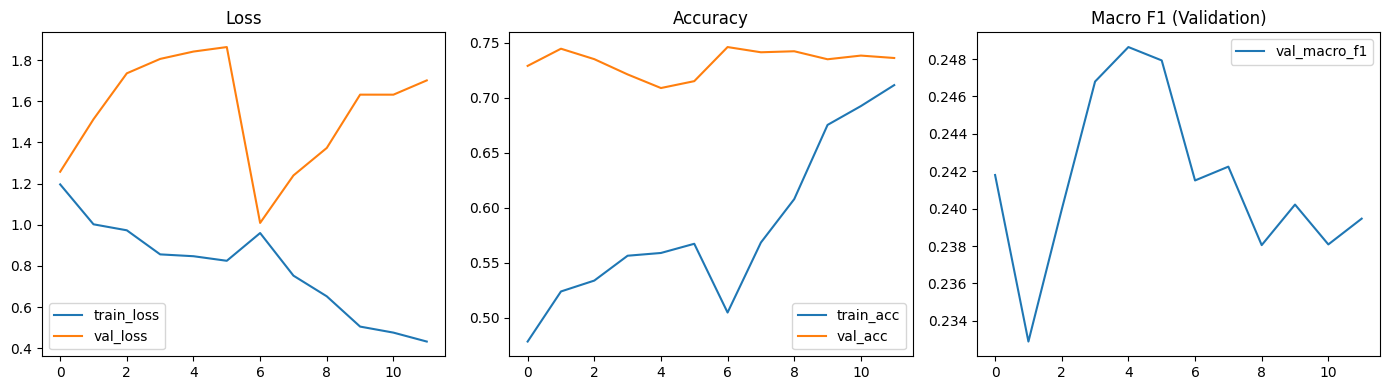

In [12]:
def merge_histories(*histories):
    merged = {}
    for hist in histories:
        for key, values in hist.history.items():
            merged.setdefault(key, []).extend(values)
    return merged

history_all = merge_histories(history_stage1, history_stage2)

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history_all.get('loss', []), label='train_loss')
plt.plot(history_all.get('val_loss', []), label='val_loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_all.get('accuracy', []), label='train_acc')
plt.plot(history_all.get('val_accuracy', []), label='val_acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_all.get('val_macro_f1', []), label='val_macro_f1')
plt.title('Macro F1 (Validation)')
plt.legend()

plt.tight_layout()
plt.show()


541/541 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step
Test Accuracy : 0.7058
Test Macro F1 : 0.2499
Test Weighted F1: 0.6697

Classification Report:
              precision    recall  f1-score   support

Non-Demented     0.7811    0.8754    0.8256      6723
   Very Mild     0.1949    0.1574    0.1742      1372
        Mild     0.0000    0.0000    0.0000       500
    Moderate     0.0000    0.0000    0.0000        49

    accuracy                         0.7058      8644
   macro avg     0.2440    0.2582    0.2499      8644
weighted avg     0.6385    0.7058    0.6697      8644



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


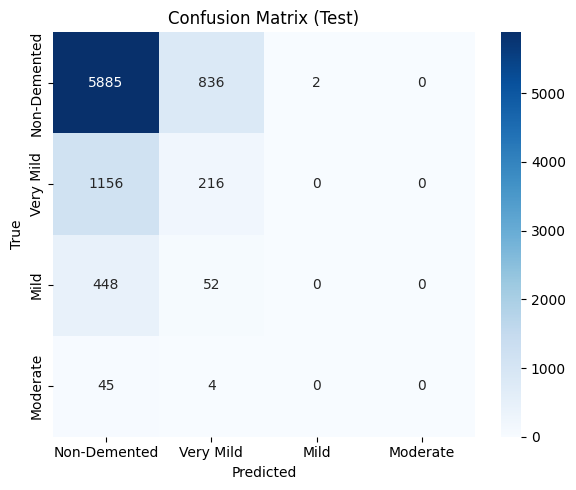

In [14]:
# Load best checkpoint selected by val_macro_f1
if best_model_path.exists():
    best_model = tf.keras.models.load_model(best_model_path)
else:
    print('Best model checkpoint not found. Using in-memory model.')
    best_model = model

probs = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(probs, axis=1)
y_true = test_df['class_id'].to_numpy().astype(int)

acc = float(accuracy_score(y_true, y_pred))
macro_f1 = float(f1_score(y_true, y_pred, average='macro'))
weighted_f1 = float(f1_score(y_true, y_pred, average='weighted'))

print(f'Test Accuracy : {acc:.4f}')
print(f'Test Macro F1 : {macro_f1:.4f}')
print(f'Test Weighted F1: {weighted_f1:.4f}')

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=[CLASS_LABELS[i] for i in range(NUM_CLASSES)], digits=4))

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
    yticklabels=[CLASS_LABELS[i] for i in range(NUM_CLASSES)],
)
plt.title('Confusion Matrix (Test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

test_metrics = {
    'accuracy': acc,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
}


In [15]:
keras_path = OUTPUT_DIR / 'mri_mobilenetv2.keras'
tflite_path = OUTPUT_DIR / 'mri_mobilenetv2_fp16.tflite'
labels_path = OUTPUT_DIR / 'mri_labels.json'
metadata_path = OUTPUT_DIR / 'mri_model_metadata.json'

best_model.save(keras_path)

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

label_payload = {str(i): CLASS_LABELS[i] for i in range(NUM_CLASSES)}
with open(labels_path, 'w', encoding='utf-8') as f:
    json.dump(label_payload, f, indent=2)

metadata = {
    'model_name': 'mri_mobilenetv2',
    'created_at_utc': datetime.utcnow().isoformat() + 'Z',
    'input': {
        'shape': [1, IMG_SIZE, IMG_SIZE, 3],
        'original_modality': 'grayscale MRI',
        'converted_to_rgb': True,
        'preprocess': 'tf.keras.applications.mobilenet_v2.preprocess_input',
    },
    'output': {
        'type': 'softmax_probabilities',
        'num_classes': NUM_CLASSES,
        'class_order': {str(i): CLASS_LABELS[i] for i in range(NUM_CLASSES)},
        'risk_map': {str(i): RISK_MAP[i] for i in range(NUM_CLASSES)},
    },
    'training': {
        'seed': SEED,
        'split': 'stratified_80_10_10',
        'batch_size': BATCH_SIZE,
        'stage1_epochs': STAGE1_EPOCHS,
        'stage2_epochs': STAGE2_EPOCHS,
    },
    'test_metrics': test_metrics,
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Saved artifacts:')
print(' -', keras_path)
print(' -', tflite_path)
print(' -', labels_path)
print(' -', metadata_path)
print('TFLite size (MB):', round(tflite_path.stat().st_size / (1024 * 1024), 2))


Saved artifact at '/tmp/tmp09eva1h7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='mri_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140257383324880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383326032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383325840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383324688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383326608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383325456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383326224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383326416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383325264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383327568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140257383326992: 

/tmp/ipykernel_621/2396461817.py:22: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'created_at_utc': datetime.utcnow().isoformat() + 'Z',


In [16]:
def preprocess_single_image_for_mobilenet(path: str):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE], method='bilinear')
    image = tf.cast(image, tf.float32)
    image = tf.image.grayscale_to_rgb(image)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    image = tf.expand_dims(image, axis=0)
    return image.numpy().astype(np.float32)

def run_tflite_inference(image_path: str):
    interpreter = tf.lite.Interpreter(model_path=str(tflite_path))
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    input_tensor = preprocess_single_image_for_mobilenet(image_path)
    interpreter.set_tensor(input_details[0]['index'], input_tensor)
    interpreter.invoke()

    probs = interpreter.get_tensor(output_details[0]['index'])[0]
    class_id = int(np.argmax(probs))
    confidence = float(probs[class_id])

    return {
        'class_id': class_id,
        'class_label': CLASS_LABELS[class_id],
        'confidence': round(confidence, 4),
        'mapped_risk': RISK_MAP[class_id],
    }

sample_row = test_df.sample(1, random_state=SEED).iloc[0]
sample_path = sample_row['filepath']
result = run_tflite_inference(sample_path)

print('Sample image:', sample_path)
print('TFLite inference result:', result)


Sample image: /content/MRI_Data_set_extracted/Data/Non Demented/OAS1_0109_MR1_mpr-3_149.jpg
TFLite inference result: {'class_id': 0, 'class_label': 'Non-Demented', 'confidence': 0.9994, 'mapped_risk': 'low'}


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [17]:
# Optional: zip artifacts for easy Colab download
import zipfile

zip_path = OUTPUT_DIR / 'mri_artifacts_bundle.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for item in [keras_path, tflite_path, labels_path, metadata_path]:
        zf.write(item, arcname=item.name)

print('Bundle created:', zip_path)


Bundle created: /content/mri_artifacts/mri_artifacts_bundle.zip


In [18]:
# Auto-download final TFLite model from Colab
from google.colab import files

if not tflite_path.exists():
    raise FileNotFoundError(f'TFLite model not found: {tflite_path}. Run export cells first.')

print(f'Downloading: {tflite_path}')
files.download(str(tflite_path))


Downloading: /content/mri_artifacts/mri_mobilenetv2_fp16.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>